In [1]:
import pyarrow.parquet as pq
import fsspec
import pyarrow as pa
import pandas as pd
from PIL import Image
import io
import os


In [2]:
url = "https://huggingface.co/datasets/stzhao/movie_posters_100k_controlnet/resolve/refs%2Fconvert%2Fparquet/default/train/0000.parquet"

N_ROW_GROUPS = 40  # ~4000 primjera

tables = []
with fsspec.open(url, "rb") as f:
    parquet_file = pq.ParquetFile(f)
    for i in range(N_ROW_GROUPS):
        table = parquet_file.read_row_group(i)
        tables.append(table)
        if i % 10 == 0:
            print(f"Pročitano {i+1}/{N_ROW_GROUPS} row groups...")

combined_table = pa.concat_tables(tables)
df = combined_table.to_pandas()

del tables
del combined_table

print(df.shape)

Pročitano 1/40 row groups...
Pročitano 11/40 row groups...
Pročitano 21/40 row groups...
Pročitano 31/40 row groups...
(4000, 17)


In [3]:
df = df.drop(columns=["ocr_result_rendered_image"], errors="ignore")
df["genre_names"] = df["genres"].apply(lambda g: [x["name"] for x in g])
df["num_genres"] = df["genre_names"].apply(len)

print(df.shape)
print(df[["title", "genre_names", "num_genres"]].head())

(4000, 18)
                                           title  \
0                                     57 Seconds   
1  Mission: Impossible - Dead Reckoning Part One   
2                                    Expend4bles   
3                               Sound of Freedom   
4                                        Nowhere   

                           genre_names  num_genres  
0  [Thriller, Science Fiction, Action]           3  
1                   [Action, Thriller]           2  
2        [Action, Adventure, Thriller]           3  
3                      [Action, Drama]           2  
4                    [Thriller, Drama]           2  


In [4]:
os.makedirs("posters", exist_ok=True)

for i, row in enumerate(df.itertuples()):
    img = Image.open(io.BytesIO(row.image["bytes"])).convert("RGB")
    img.save(f"posters/{row.id}.jpg", quality=85)
    img.close()
    if i % 500 == 0:
        print(f"Spremljeno {i}/{len(df)}...")

print("Sve slike spremljene na disk.")

Spremljeno 0/4000...
Spremljeno 500/4000...
Spremljeno 1000/4000...
Spremljeno 1500/4000...
Spremljeno 2000/4000...
Spremljeno 2500/4000...
Spremljeno 3000/4000...
Spremljeno 3500/4000...
Sve slike spremljene na disk.


In [5]:
import os

files = os.listdir("posters")
print(f"Broj spremljenih slika: {len(files)}")

!du -sh posters/
!df -h /

Broj spremljenih slika: 4000
267M	posters/
Filesystem      Size  Used Avail Use% Mounted on
/dev/root       119G   74G   45G  63% /


In [6]:
import os
print(os.getcwd())

/mnt/batch/tasks/shared/LS_root/mounts/clusters/iculjak7/code/Users/iculjak


In [7]:
df = df.drop(columns=["image"])
df.to_csv("movie_genre_metadata.csv", index=False)

print(df.shape)
print("Metapodaci spremljeni u movie_genre_metadata.csv")

(4000, 17)
Metapodaci spremljeni u movie_genre_metadata.csv


In [8]:
print("Broj filmova:", len(df))
print("Broj jedinstvenih žanrova:", df["genre_names"].explode().nunique())
print()
print(df[["popularity", "budget", "revenue", "runtime"]].describe())

Broj filmova: 4000
Broj jedinstvenih žanrova: 19

        popularity        budget       revenue      runtime
count  4000.000000  4.000000e+03  4.000000e+03  4000.000000
mean     42.549582  2.497664e+07  8.441216e+07   103.758000
std      92.777488  4.572040e+07  1.979399e+08    26.941806
min      14.584000  0.000000e+00  0.000000e+00     0.000000
25%      17.955250  0.000000e+00  0.000000e+00    92.000000
50%      23.408000  1.800000e+06  3.492626e+06   103.000000
75%      37.801250  3.000000e+07  7.886915e+07   117.000000
max    3132.329000  4.600000e+08  2.923706e+09   248.000000


Matplotlib is building the font cache; this may take a moment.


Drama              1459
Action             1181
Thriller           1123
Comedy             1037
Adventure           803
Horror              660
Fantasy             583
Animation           567
Science Fiction     548
Romance             536
Crime               516
Family              508
Mystery             384
History             176
War                 122
Music                94
Documentary          67
TV Movie             55
Western              40
Name: genre_names, dtype: int64


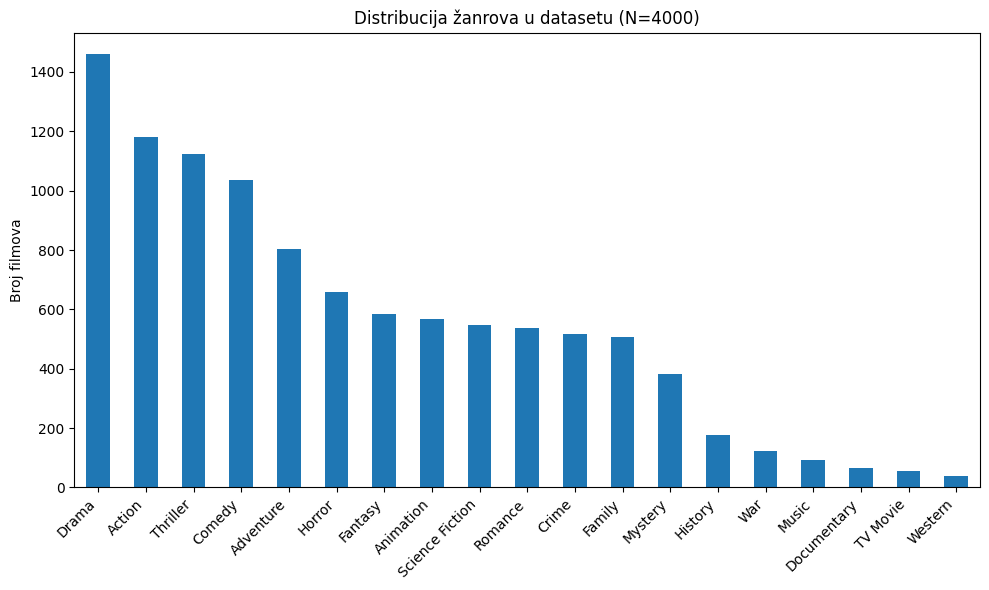

In [9]:
import matplotlib.pyplot as plt

genre_counts = df["genre_names"].explode().value_counts()
print(genre_counts)

plt.figure(figsize=(10,6))
genre_counts.plot(kind="bar")
plt.title("Distribucija žanrova u datasetu (N=4000)")
plt.ylabel("Broj filmova")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("genre_distribution.png")
plt.show()

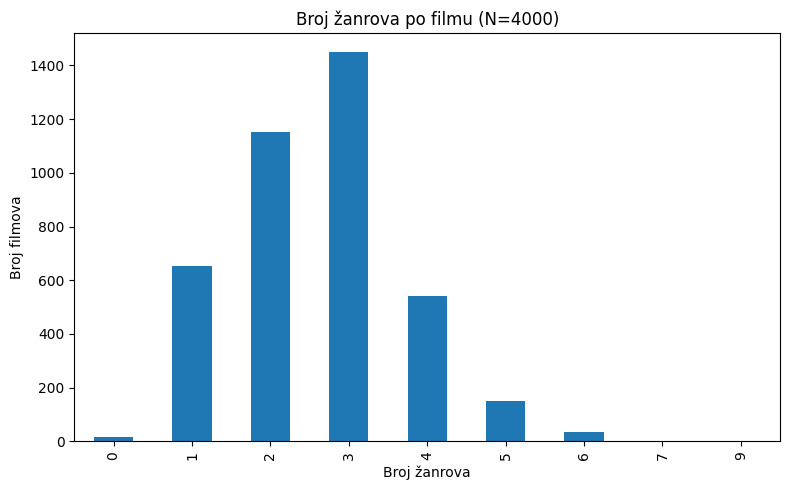

0      15
1     654
2    1151
3    1449
4     542
5     152
6      33
7       3
9       1
Name: num_genres, dtype: int64


In [10]:
plt.figure(figsize=(8,5))
df["num_genres"].value_counts().sort_index().plot(kind="bar")
plt.title("Broj žanrova po filmu (N=4000)")
plt.xlabel("Broj žanrova")
plt.ylabel("Broj filmova")
plt.tight_layout()
plt.savefig("genres_per_movie.png")
plt.show()

print(df["num_genres"].value_counts().sort_index())

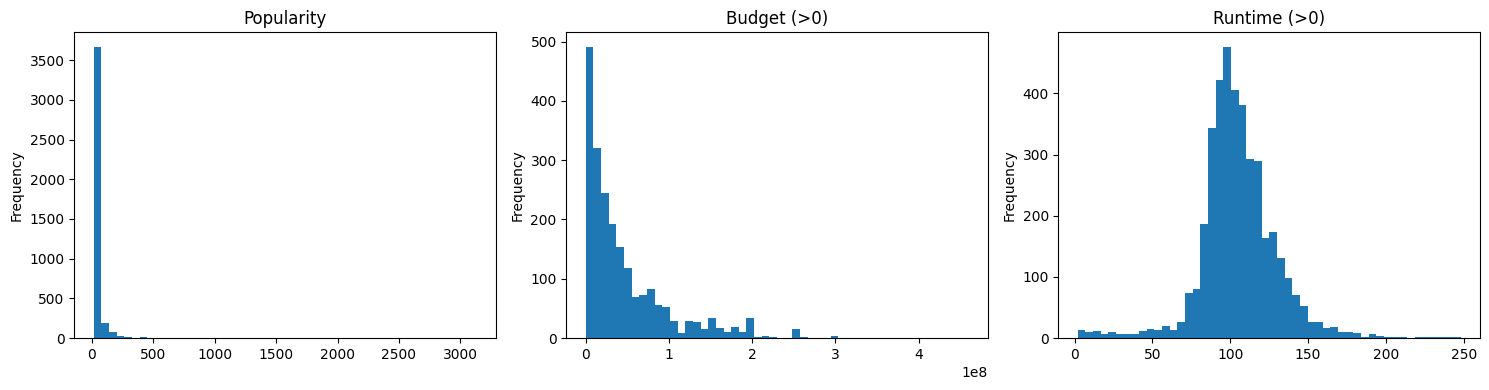

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df["popularity"].plot(kind="hist", bins=50, ax=axes[0], title="Popularity")
df[df["budget"]>0]["budget"].plot(kind="hist", bins=50, ax=axes[1], title="Budget (>0)")
df[df["runtime"]>0]["runtime"].plot(kind="hist", bins=50, ax=axes[2], title="Runtime (>0)")
plt.tight_layout()
plt.savefig("numeric_distributions.png")
plt.show()

In [12]:
print(df["original_language"].value_counts().head(10))

en    2975
ja     237
es     154
ko     148
fr     115
zh      51
ru      41
tl      35
it      31
de      28
Name: original_language, dtype: int64


In [13]:
from scipy import stats

df["is_action"] = df["genre_names"].apply(lambda g: "Action" in g)
action_budget = df[(df["is_action"]) & (df["budget"]>0)]["budget"]
non_action_budget = df[(~df["is_action"]) & (df["budget"]>0)]["budget"]

t_stat, p_value = stats.ttest_ind(action_budget, non_action_budget, equal_var=False)
print(f"Action filmovi - prosječni budget: {action_budget.mean():,.0f}")
print(f"Non-Action filmovi - prosječni budget: {non_action_budget.mean():,.0f}")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.6f}")

Action filmovi - prosječni budget: 73,671,660
Non-Action filmovi - prosječni budget: 33,459,290
t-statistic: 14.798, p-value: 0.000000
